In [ ]:
!pip install addfips
!pip install us

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 7.2 MB/s eta 0:00:00


# MASTER CODE

In [ ]:
# standard stuff
import numpy as np
import pandas as pd
# country Map
import plotly.express as px
import addfips
import us
# Regretion stuff
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error, median_absolute_error
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
#gradient boosting stuff
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import json
from urllib.request import urlopen
from sklearn.model_selection import cross_val_score, KFold

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from google.colab import drive
import re


## Optional Run

In [ ]:
VegData = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTU6WAz3UfcApC4kZVCDhdYwU8FemgPqRv4DKM9QqAwoeD3xZbCSBRxCqgYlunKUw/pub?gid=787104991&single=true&output=csv')
Veg_df = pd.DataFrame(VegData)
Veg_df

,country,subnational1,subnational2,threshold,area_ha,extent_2000_ha,extent_2010_ha,gain_2000-2020_ha,tc_loss_ha_2001,tc_loss_ha_2002,...,tc_loss_ha_2014,tc_loss_ha_2015,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023
0,United States,Alabama,Autauga,0,156174,156174,156174,9783,2848,1640,...,1954,2361,2889,3285,2415,2373,1990,2366,1666,1757
1,United States,Alabama,Autauga,10,156174,109666,103665,9783,2831,1634,...,1711,1839,2177,2675,1786,1830,1481,1855,1337,1316
2,United States,Alabama,Autauga,15,156174,108202,102662,9783,2830,1633,...,1706,1826,2164,2655,1774,1815,1471,1841,1326,1302
3,United States,Alabama,Autauga,20,156174,106621,100894,9783,2823,1631,...,1692,1807,2140,2627,1755,1788,1453,1818,1305,1279
4,United States,Alabama,Autauga,25,156174,105337,100504,9783,2819,1630,...,1685,1792,2122,2609,1742,1771,1438,1800,1291,1263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25179,United States,Wyoming,Weston,20,623139,30023,18994,1072,455,30,...,610,243,41,659,1365,146,105,45,51,207
25180,United States,Wyoming,Weston,25,623139,25585,17336,1072,317,29,...,549,227,33,619,1315,128,85,27,37,148
25181,United States,Wyoming,Weston,30,623139,23213,16177,1072,255,25,...,518,217,30,596,1286,119,74,20,32,126
25182,United States,Wyoming,Weston,50,623139,12607,3772,1072,126,16,...,306,117,12,316,988,83,22,3,11,27


In [ ]:
combined_aqi = pd.read_csv("/content/combined_aqi.csv")
combined_aqi


,Parameter Name,Metric Used,Year,Units of Measure,Completeness Indicator,Null Data Count,Arithmetic Mean,Arithmetic Standard Dev,1st Max Value,1st Max DateTime,...,2nd Max DateTime,3rd Max Value,3rd Max DateTime,4th Max Value,4th Max DateTime,Local Site Name,Address,State Name,County Name,City Name
0,Ozone,Daily maxima of observed hourly values (betwee...,2016,Parts per million,Y,458,0.045114,0.011791,0.074,2016-04-05 13:00,...,2016-05-14 16:00,0.069,2016-05-07 15:00,0.069,2016-06-09 15:00,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope
1,Ozone,Daily maximum of 8 hour running average of obs...,2016,Parts per million,Y,0,0.040624,0.011092,0.066,2016-05-14 11:00,...,2016-05-08 09:00,0.063,2016-05-07 11:00,0.062,2016-05-23 09:00,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope
2,Ozone,Daily maximum of 8 hour running average of obs...,2016,Parts per million,Y,0,0.040624,0.011092,0.066,2016-05-14 11:00,...,2016-05-08 09:00,0.063,2016-05-07 11:00,0.062,2016-05-23 09:00,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope
3,Ozone,Daily maximum of 8-hour running average,2016,Parts per million,Y,0,0.040509,0.011027,0.066,2016-05-14 11:00,...,2016-05-08 09:00,0.063,2016-05-07 11:00,0.062,2016-05-23 09:00,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope
4,Average Ambient Temperature,Observed Values,2016,Degrees Centigrade,N,0,19.008333,6.909347,29.600,2016-06-26 00:00,...,2016-06-17 00:00,28.500,2016-06-08 00:00,28.300,2016-05-30 00:00,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19660,PM2.5 - Local Conditions,Quarterly Means of Daily Means,2016,Micrograms/cubic meter (LC),Y,6,6.708621,3.216360,26.800,2016-11-14 00:00,...,2016-09-24 00:00,12.800,2016-03-22 00:00,12.600,2016-06-11 00:00,Lawrence Co ozone monitor,355 BUSBY RD,Tennessee,Lawrence,Loretto
19661,PM2.5 - Local Conditions,Quarterly Means of Daily Means,2016,Micrograms/cubic meter (LC),Y,6,6.708621,3.216360,26.800,2016-11-14 00:00,...,2016-09-24 00:00,12.800,2016-03-22 00:00,12.600,2016-06-11 00:00,Lawrence Co ozone monitor,355 BUSBY RD,Tennessee,Lawrence,Loretto
19662,Ozone,Daily maxima of observed hourly values (betwee...,2016,Parts per million,Y,483,0.054106,0.012012,0.096,2016-06-10 17:00,...,2016-06-11 12:00,0.082,2016-06-09 16:00,0.082,2016-07-20 16:00,Loudon Pope site,130 WEBB DRIVE Loudon TN 37774,Tennessee,Loudon,Loudon
19663,Ozone,Daily maximum of 8 hour running average of obs...,2016,Parts per million,Y,0,0.048877,0.011031,0.083,2016-06-10 12:00,...,2016-04-20 11:00,0.074,2016-06-11 10:00,0.073,2016-04-18 11:00,Loudon Pope site,130 WEBB DRIVE Loudon TN 37774,Tennessee,Loudon,Loudon


In [ ]:
af = addfips.AddFIPS()


for index, row_data in VegData.iterrows():
    State = row_data['subnational1']
    County = row_data['subnational2']

    Fips = af.get_county_fips(County, state=State)
    VegData.loc[index, 'Fips Code'] = Fips

In [ ]:
mort_master = pd.read_csv("/content/mortality_merged_2000_2016.csv")
mort_master

,County,County Code,crude_2000,crude_2001,crude_2002,crude_2003,crude_2004,crude_2005,crude_2006,crude_2007,...,crude_2009,crude_2010,crude_2011,crude_2012,crude_2013,crude_2014,crude_2015,crude_2016,avg_crude_rate,years_with_data
0,"Abbeville County, SC",45001,61.1,83.6,76.0,57.0,87.7,42.3,96.8,77.7,...,97.6,133.8,151.4,111.8,88.1,100.4,168.2,148.8,99.488235,17
1,"Acadia Parish, LA",22001,98.5,93.5,81.3,89.5,65.9,87.4,89.2,77.4,...,65.1,76.1,59.9,90.5,109.4,100.7,95.8,91.0,84.605882,17
2,"Accomack County, VA",51001,91.4,84.8,72.4,114.3,107.4,103.3,119.3,115.8,...,110.7,135.7,153.2,120.0,118.1,133.2,103.0,112.3,111.988235,17
3,"Ada County, ID",16001,66.5,62.4,59.4,63.2,51.4,65.9,62.2,60.5,...,63.1,57.1,68.6,55.0,54.5,62.4,65.5,66.0,61.264706,17
4,"Adair County, IA",19001,182.0,258.2,248.2,186.3,NaN,NaN,302.9,127.0,...,143.3,143.2,145.4,200.2,161.3,148.3,NaN,141.0,182.507143,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2880,"Yuba County, CA",6115,112.9,91.4,114.3,111.6,73.7,117.7,99.6,84.8,...,74.0,67.9,106.1,87.8,124.3,96.2,99.6,108.9,96.905882,17
2881,"Yuma County, AZ",4027,64.4,80.4,91.3,81.5,82.2,95.6,80.5,66.7,...,85.7,91.4,87.9,97.0,79.8,81.7,80.0,73.4,82.111765,17
2882,"Yuma County, CO",8125,111.8,112.0,NaN,120.9,112.3,133.1,NaN,132.8,...,139.7,NaN,187.1,118.6,NaN,NaN,168.4,99.0,130.650000,12
2883,"Zapata County, TX",48505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,86.5,NaN,NaN,NaN,NaN,NaN,97.2,NaN,91.850000,2


In [ ]:

try:
    import addfips
except ImportError:
    raise ImportError("Please install addfips first: pip install addfips")

af = addfips.AddFIPS()


def clean_county(x):
    x = str(x).strip().lower()
    x = re.sub(r',\s*[a-z]{2}$', '', x)
    x = re.sub(r'\s+(county|parish|borough|city|district|census area|municipality)$', '', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x

def slugify(x):
    x = str(x).lower()
    x = re.sub(r'[^a-z0-9]+', '_', x)
    return x.strip('_')

def to_fips(series):
    nums = pd.to_numeric(series, errors='coerce')
    return nums.apply(lambda v: f"{int(v):05d}" if pd.notna(v) else pd.NA)


mort_path = "mortality_merged_2000_2016.csv"
mort_master = pd.read_csv(mort_path)

crude_cols = [c for c in mort_master.columns if re.match(r"^crude_\d{4}$", c)]
base_cols = [c for c in mort_master.columns if c not in crude_cols]

mort_long = mort_master.melt(
    id_vars=base_cols,
    value_vars=crude_cols,
    var_name="year",
    value_name="crude_rate"
)

mort_long["year"] = mort_long["year"].str.extract(r"(\d{4})").astype(int)


mort_long["fips"] = to_fips(mort_long["County Code"])
mort_long["county_clean"] = mort_long["County"].apply(clean_county)

mort_long = mort_long.sort_values(["fips", "year"]).reset_index(drop=True)


aqi = pd.read_csv("combined_aqi.csv")

aqi["year"] = pd.to_numeric(aqi["Year"], errors="coerce").astype("Int64")
aqi["fips"] = aqi.apply(
    lambda r: af.get_county_fips(str(r["County Name"]), state=str(r["State Name"])),
    axis=1
)
aqi["fips"] = aqi["fips"].apply(lambda x: f"{int(x):05d}" if pd.notna(x) else pd.NA)

aqi_keep = aqi[
    (
        (aqi["Parameter Name"].eq("Ozone") & aqi["Metric Used"].str.contains("8 hour", case=False, na=False))
        |
        (aqi["Parameter Name"].eq("PM2.5 - Local Conditions") & aqi["Metric Used"].str.contains("Daily Mean", case=False, na=False))
        |
        (aqi["Parameter Name"].eq("Nitrogen dioxide (NO2)") & aqi["Metric Used"].str.contains("1-hour", case=False, na=False))
        |
        (aqi["Parameter Name"].eq("Sulfur dioxide (SO2)") & aqi["Metric Used"].str.contains("1-hour", case=False, na=False))
        |
        (aqi["Parameter Name"].eq("Carbon monoxide") & aqi["Metric Used"].str.contains("8-hour", case=False, na=False))
        |
        (aqi["Parameter Name"].isin([
            "Average Ambient Temperature",
            "Outdoor Temperature",
            "Wind Speed - Resultant",
            "Wind Direction - Resultant",
            "Precipitation"
        ]))
    )
].copy()

aqi_grouped = (
    aqi_keep.groupby(["fips", "year", "Parameter Name"], as_index=False)["Arithmetic Mean"]
    .mean()
)

aqi_wide = (
    aqi_grouped.pivot_table(
        index=["fips", "year"],
        columns="Parameter Name",
        values="Arithmetic Mean",
        aggfunc="mean"
    )
    .reset_index()
)

aqi_wide.columns = [
    "fips" if c == "fips" else
    "year" if c == "year" else
    f"aqi_{slugify(c)}"
    for c in aqi_wide.columns
]


veg = pd.read_csv(
    "https://docs.google.com/spreadsheets/d/e/2PACX-1vTU6WAz3UfcApC4kZVCDhdYwU8FemgPqRv4DKM9QqAwoeD3xZbCSBRxCqgYlunKUw/pub?gid=787104991&single=true&output=csv"
)

county_candidates = ["subnational2", "County", "County Name", "county"]
state_candidates = ["subnational1", "State", "State Name", "state"]

county_col = next((c for c in county_candidates if c in veg.columns), None)
state_col = next((c for c in state_candidates if c in veg.columns), None)

if county_col is None or state_col is None:
    raise ValueError(f"Could not find county/state columns in vegetation file. Columns are: {list(veg.columns)}")

veg["county_clean"] = veg[county_col].apply(clean_county)
veg["fips"] = veg.apply(
    lambda r: af.get_county_fips(str(r[county_col]), state=str(r[state_col])),
    axis=1
)
veg["fips"] = veg["fips"].apply(lambda x: f"{int(x):05d}" if pd.notna(x) else pd.NA)

if "threshold" in veg.columns:
    veg = veg[veg["threshold"] == 30].copy()

veg_year_cols = [c for c in veg.columns if re.match(r"^tc_loss_ha_\d{4}$", c)]

static_cols = [c for c in veg.columns if c not in veg_year_cols]

veg_long = veg.melt(
    id_vars=static_cols,
    value_vars=veg_year_cols,
    var_name="year",
    value_name="veg_treecover_loss_ha"
)

veg_long["year"] = veg_long["year"].str.extract(r"(\d{4})").astype(int)

agg_dict = {}
for c in veg_long.columns:
    if c in ["fips", "year"]:
        continue
    if c == "veg_treecover_loss_ha":
        agg_dict[c] = "mean"
    elif pd.api.types.is_numeric_dtype(veg_long[c]):
        agg_dict[c] = "first"
    else:
        agg_dict[c] = "first"

veg_yearly = veg_long.groupby(["fips", "year"], as_index=False).agg(agg_dict)

final = mort_long.merge(
    aqi_wide,
    on=["fips", "year"],
    how="left",
    validate="1:1"
)

final = final.merge(
    veg_yearly,
    on=["fips", "year"],
    how="left",
    validate="1:1"
)


print(final)

final.to_csv("everything_master.csv", index=False)

                   County  County Code  avg_crude_rate  years_with_data  year  \
0      Autauga County, AL         1001       83.658824               17  2000   
1      Autauga County, AL         1001       83.658824               17  2001   
2      Autauga County, AL         1001       83.658824               17  2002   
3      Autauga County, AL         1001       83.658824               17  2003   
4      Autauga County, AL         1001       83.658824               17  2004   
...                   ...          ...             ...              ...   ...   
49040   Weston County, WY        56045      170.550000                8  2012   
49041   Weston County, WY        56045      170.550000                8  2013   
49042   Weston County, WY        56045      170.550000                8  2014   
49043   Weston County, WY        56045      170.550000                8  2015   
49044   Weston County, WY        56045      170.550000                8  2016   

       crude_rate   fips co

In [ ]:
mort_long = mort_master.melt(
    id_vars=["County", "County Code"],
    value_vars=[f"crude_{year}" for year in range(2000, 2017)],
    var_name="year",
    value_name="crude_rate"
)

mort_long["year"] = mort_long["year"].str.extract(r"(\d+)").astype(int)

mort_long.head()

,County,County Code,year,crude_rate
0,"Abbeville County, SC",45001,2000,61.1
1,"Acadia Parish, LA",22001,2000,98.5
2,"Accomack County, VA",51001,2000,91.4
3,"Ada County, ID",16001,2000,66.5
4,"Adair County, IA",19001,2000,182.0


In [ ]:
mort_long["county_clean"] = (mort_long["County"]
    .str.split(",").str[0]
    .str.lower()
    .str.replace(" county", "", regex=False)
    .str.replace(" parish", "", regex=False)
    .str.strip()
)


combined_aqi["county_clean"] = (combined_aqi["County Name"]
    .str.lower()
    .str.replace(" county", "", regex=False)
    .str.replace(" parish", "", regex=False)
    .str.strip()
)

mort_long["state"] = mort_long["County"].str.split(",").str[-1].str.strip()

final_df = mort_long.merge(
    combined_aqi,
    left_on=["county_clean", "state", "year"],
    right_on=["county_clean", "State Name", "Year"],
    how="left"
)
final_df

,County,County Code,year,crude_rate,county_clean,state,Parameter Name,Metric Used,Year,Units of Measure,...,2nd Max DateTime,3rd Max Value,3rd Max DateTime,4th Max Value,4th Max DateTime,Local Site Name,Address,State Name,County Name,City Name
0,"Abbeville County, SC",45001,2000,61.1,abbeville,SC,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Acadia Parish, LA",22001,2000,98.5,acadia,LA,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Accomack County, VA",51001,2000,91.4,accomack,VA,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Ada County, ID",16001,2000,66.5,ada,ID,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Adair County, IA",19001,2000,182.0,adair,IA,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49040,"Yuba County, CA",6115,2016,108.9,yuba,CA,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49041,"Yuma County, AZ",4027,2016,73.4,yuma,AZ,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49042,"Yuma County, CO",8125,2016,99.0,yuma,CO,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49043,"Zapata County, TX",48505,2016,NaN,zapata,TX,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Start of Activly Used Code

In [ ]:
everything_master = pd.read_csv("/content/everything_master.csv")
everything_master

,County,County Code,avg_crude_rate,years_with_data,year,crude_rate,fips,county_clean_x,aqi_average_ambient_temperature,aqi_nitrogen_dioxide_no2,...,country,subnational1,subnational2,threshold,area_ha,extent_2000_ha,extent_2010_ha,gain_2000-2020_ha,county_clean_y,veg_treecover_loss_ha
0,"Autauga County, AL",1001,83.658824,17,2000,50.4,1001,autauga,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Autauga County, AL",1001,83.658824,17,2001,51.2,1001,autauga,NaN,NaN,...,United States,Alabama,Autauga,30.0,156174.0,103485.0,96833.0,9783.0,autauga,2810.0
2,"Autauga County, AL",1001,83.658824,17,2002,80.6,1001,autauga,NaN,NaN,...,United States,Alabama,Autauga,30.0,156174.0,103485.0,96833.0,9783.0,autauga,1628.0
3,"Autauga County, AL",1001,83.658824,17,2003,96.2,1001,autauga,NaN,NaN,...,United States,Alabama,Autauga,30.0,156174.0,103485.0,96833.0,9783.0,autauga,1306.0
4,"Autauga County, AL",1001,83.658824,17,2004,64.1,1001,autauga,NaN,NaN,...,United States,Alabama,Autauga,30.0,156174.0,103485.0,96833.0,9783.0,autauga,2918.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49040,"Weston County, WY",56045,170.550000,8,2012,NaN,56045,weston,NaN,NaN,...,United States,Wyoming,Weston,30.0,623139.0,23213.0,16177.0,1072.0,weston,2150.0
49041,"Weston County, WY",56045,170.550000,8,2013,139.6,56045,weston,NaN,NaN,...,United States,Wyoming,Weston,30.0,623139.0,23213.0,16177.0,1072.0,weston,1036.0
49042,"Weston County, WY",56045,170.550000,8,2014,195.0,56045,weston,NaN,NaN,...,United States,Wyoming,Weston,30.0,623139.0,23213.0,16177.0,1072.0,weston,518.0
49043,"Weston County, WY",56045,170.550000,8,2015,NaN,56045,weston,NaN,13.736747,...,United States,Wyoming,Weston,30.0,623139.0,23213.0,16177.0,1072.0,weston,217.0


In [ ]:
final_master = everything_master.dropna(subset=everything_master.columns[9:15], how="all")

In [ ]:
cols_remove = ["years_with_data", "fips", "county_clean_x", "county_clean_y", "country", "subnational1", "subnational2", "threshold", "area_ha", "extent_2000_ha", "extent_2010_ha", "gain_2000-2020_ha"]
final_master_clean = final_master.drop(columns = cols_remove)
final_master_clean
final_master_clean.to_csv("final_master_clean.csv", index=False)

In [ ]:
final_master_clean

,County,County Code,avg_crude_rate,year,crude_rate,aqi_average_ambient_temperature,aqi_nitrogen_dioxide_no2,aqi_outdoor_temperature,aqi_ozone,aqi_pm2_5_local_conditions,aqi_wind_direction_resultant,aqi_wind_speed_resultant,veg_treecover_loss_ha
17,"Baldwin County, AL",1003,83.223529,2000,80.5,21.823333,NaN,NaN,0.054953,14.834118,NaN,NaN,NaN
18,"Baldwin County, AL",1003,83.223529,2001,82.8,20.186239,NaN,NaN,0.046201,10.552586,NaN,NaN,4344.0
19,"Baldwin County, AL",1003,83.223529,2002,66.9,19.055769,NaN,NaN,0.041113,10.232743,NaN,NaN,3434.0
20,"Baldwin County, AL",1003,83.223529,2003,81.8,20.208772,NaN,NaN,0.041756,12.169298,NaN,NaN,3213.0
21,"Baldwin County, AL",1003,83.223529,2004,78.1,19.301802,NaN,NaN,0.046952,11.316375,NaN,NaN,6484.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49040,"Weston County, WY",56045,170.550000,2012,NaN,NaN,NaN,50.129242,NaN,NaN,NaN,NaN,2150.0
49041,"Weston County, WY",56045,170.550000,2013,139.6,NaN,NaN,45.950187,0.050868,NaN,NaN,NaN,1036.0
49042,"Weston County, WY",56045,170.550000,2014,195.0,NaN,NaN,45.604651,0.047290,NaN,NaN,NaN,518.0
49043,"Weston County, WY",56045,170.550000,2015,NaN,NaN,13.736747,49.764530,0.045934,6.072180,153.194901,3.995092,217.0


In [ ]:
print(final_master_clean.columns)

Index(['County', 'County Code', 'avg_crude_rate', 'year', 'crude_rate',
       'aqi_average_ambient_temperature', 'aqi_nitrogen_dioxide_no2',
       'aqi_outdoor_temperature', 'aqi_ozone', 'aqi_pm2_5_local_conditions',
       'aqi_wind_direction_resultant', 'aqi_wind_speed_resultant',
       'veg_treecover_loss_ha'],
      dtype='object')


In [ ]:
CountyName = 'County'
CountyCode = 'County Code'
avg_crude_rate = 'Average Crude Rate'
year = 'Year'
crude_rate = 'Crude Rate'
aqi_average_ambient_temperature = 'Average Ambient Temperature'
aqi_nitrogen_dioxide_no2 = 'Nitrogen Dioxide (NO₂)'
aqi_outdoor_temperature = 'Outdoor Temperature'
aqi_ozone = 'Ozone'
aqi_pm2_5_local_conditions = 'PM₂.₅'
aqi_wind_direction_resultant = 'Wind Direction'
aqi_wind_speed_resultant = 'Wind Speed'
veg_treecover_loss_ha = 'Treecover Loss'

final_master_clean.columns = [CountyName, CountyCode, avg_crude_rate, year, crude_rate, aqi_average_ambient_temperature, aqi_nitrogen_dioxide_no2, aqi_outdoor_temperature, aqi_ozone, aqi_pm2_5_local_conditions, aqi_wind_direction_resultant, aqi_wind_speed_resultant, veg_treecover_loss_ha]

In [ ]:
print(final_master_clean.columns)

Index(['County', 'County Code', 'Average Crude Rate', 'Year', 'Crude Rate',
       'Average Ambient Temperature', 'Nitrogen Dioxide (NO₂)',
       'Outdoor Temperature', 'Ozone', 'PM₂.₅', 'Wind Direction', 'Wind Speed',
       'Treecover Loss'],
      dtype='object')


In [ ]:
reduced = final_master_clean[[CountyName,crude_rate,aqi_nitrogen_dioxide_no2,aqi_outdoor_temperature,aqi_ozone,aqi_pm2_5_local_conditions,aqi_wind_speed_resultant,veg_treecover_loss_ha]]
test_df = reduced.dropna()
test_df

,County,Crude Rate,Nitrogen Dioxide (NO₂),Outdoor Temperature,Ozone,PM₂.₅,Wind Speed,Treecover Loss
625,"Jefferson County, AL",89.3,23.141935,16.833078,0.039991,10.427052,1.766310,1788.0
626,"Jefferson County, AL",81.7,25.704919,62.969060,0.041577,10.921965,1.082529,2044.0
627,"Jefferson County, AL",96.1,24.544025,65.131563,0.039798,10.628263,3.140299,2079.0
628,"Jefferson County, AL",94.8,26.159821,66.312466,0.044556,9.538187,1.751694,2052.0
1437,"Maricopa County, AZ",64.3,35.565945,77.326915,0.048730,9.213364,3.248792,3.0
...,...,...,...,...,...,...,...,...
48972,"Sweetwater County, WY",84.3,11.627704,45.059393,0.051302,6.435980,8.900163,3.0
48973,"Sweetwater County, WY",68.7,10.941406,39.958956,0.049267,3.556493,8.035048,0.0
48974,"Sweetwater County, WY",80.1,8.992464,42.876998,0.048659,3.092274,9.033209,0.0
48975,"Sweetwater County, WY",60.4,9.165967,43.943281,0.048794,4.781667,8.165617,0.0


## Regression Stuff
setting up Regretion related models

In [ ]:
Main_df = test_df.loc[:, aqi_nitrogen_dioxide_no2:veg_treecover_loss_ha]
Target = test_df[crude_rate]
County_Series = test_df[CountyName]

X_train, X_test, y_train, y_test, county_train, county_test = train_test_split(
    Main_df, Target, County_Series, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Execution

#### Gradient Boosting

Best number of trees: 204
Train R²: 0.2991998394470363
Test R²: 0.17585341717936676
                         County  Actual  Predicted
0            Baltimore city, MD    93.6  76.108517
1        San Joaquin County, CA    65.9  67.268819
2             Orange County, TX   116.1  76.323943
3             Travis County, TX    32.0  76.074463
4             Fresno County, CA    64.5  69.719451
..                          ...     ...        ...
234            Adams County, CO    75.6  73.914001
235       St. Joseph County, IN    95.1  75.629655
236            Scott County, IA    82.3  76.334201
237  San Luis Obispo County, CA    76.8  79.328608
238         Hamilton County, OH    90.7  74.438650

[239 rows x 3 columns]

MAE: 15.710924982969047
R²: 0.17585341717936676

Nitrogen Dioxide (NO₂)   -0.316766
Outdoor Temperature      -0.245269
PM₂.₅                    -0.169915
Treecover Loss           -0.017119
Wind Speed                0.027995
Ozone                     0.052942
Crude Rate          

Text(0, 0.5, 'Predicted')

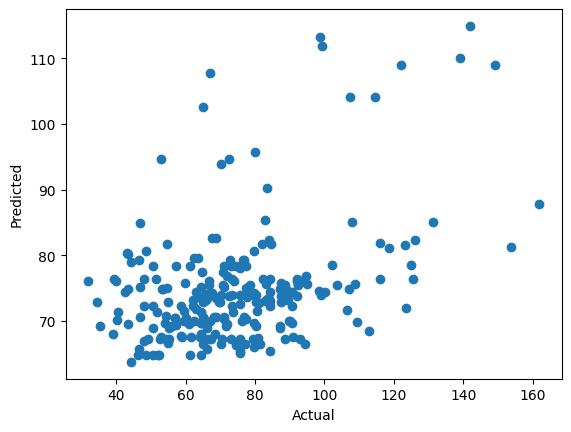

In [ ]:
model = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=2,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=50
)

model.fit(X_train, y_train)

print("Best number of trees:", model.n_estimators_)


y_pred = model.predict(X_test)
print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

results = pd.DataFrame({
    'County': county_test.values,
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results)
print("")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))
print("")
corrs = test_df.corr(numeric_only=True)[crude_rate].sort_values()
print(corrs)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [ ]:
importances = model.feature_importances_


feat_imp = pd.Series(importances, index=Main_df.columns)


feat_imp = feat_imp.sort_values(ascending=False)
print(feat_imp.head(10))

Nitrogen Dioxide (NO₂)    0.588120
Outdoor Temperature       0.176432
Ozone                     0.081272
PM₂.₅                     0.058663
Wind Speed                0.054700
Treecover Loss            0.040812
dtype: float64


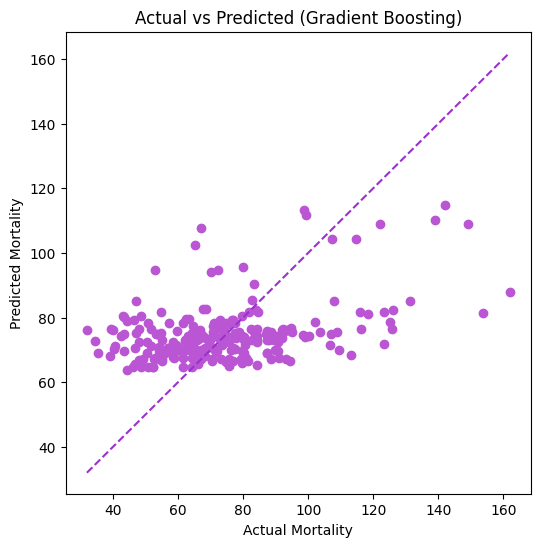

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color = 'mediumorchid')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', color = 'darkorchid')
plt.xlabel("Actual Mortality")
plt.ylabel("Predicted Mortality")
plt.title("Actual vs Predicted (Gradient Boosting)")
plt.show()

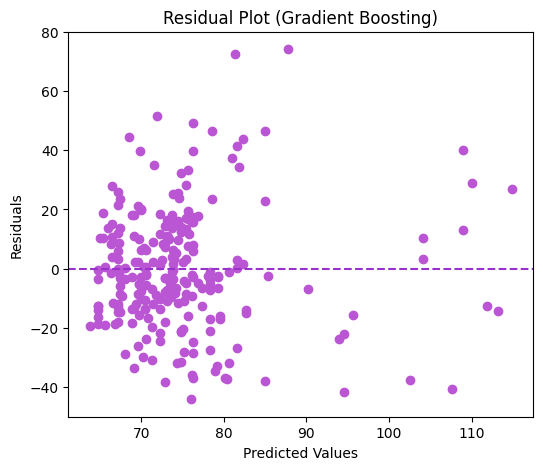

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, color = 'mediumorchid')
plt.axhline(0, linestyle='--', color = 'darkorchid')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Gradient Boosting)")
plt.show()

#### Random Forest

Train R²: 0.6377219566626591
Test R²: 0.3556088611984236
                         County  Actual  Predicted
0            Baltimore city, MD    93.6  79.177076
1        San Joaquin County, CA    65.9  67.434181
2             Orange County, TX   116.1  84.325584
3             Travis County, TX    32.0  59.873692
4             Fresno County, CA    64.5  70.719857
..                          ...     ...        ...
234            Adams County, CO    75.6  71.213273
235       St. Joseph County, IN    95.1  80.971307
236            Scott County, IA    82.3  82.065770
237  San Luis Obispo County, CA    76.8  76.266112
238         Hamilton County, OH    90.7  80.868219

[239 rows x 3 columns]

MAE: 13.738523141052537
R²: 0.3556088611984236

Nitrogen Dioxide (NO₂)   -0.316766
Outdoor Temperature      -0.245269
PM₂.₅                    -0.169915
Treecover Loss           -0.017119
Wind Speed                0.027995
Ozone                     0.052942
Crude Rate                1.000000
Name: Crude R

Text(0, 0.5, 'Predicted')

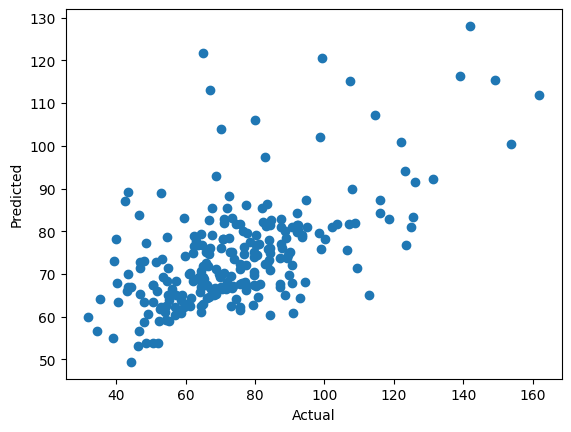

In [ ]:
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    bootstrap=True,
    random_state=50
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

results = pd.DataFrame({
    'County': county_test.values,
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results)
print("")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))
print("")
corrs = test_df.corr(numeric_only=True)[crude_rate].sort_values()
print(corrs)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [ ]:
importances = model.feature_importances_


feat_imp = pd.Series(importances, index=Main_df.columns)


feat_imp = feat_imp.sort_values(ascending=False)
print(feat_imp.head(10))

Nitrogen Dioxide (NO₂)    0.316937
Outdoor Temperature       0.173442
PM₂.₅                     0.148939
Wind Speed                0.144035
Ozone                     0.128075
Treecover Loss            0.088573
dtype: float64


### Interpretation
because we are working with enviromental factors related to mortality (something that is very complex and has more factors than we have data for) a R^2 of between 0.2 and 0.4 is acceptable. it's not ideal but it still gives insight into how these variables factor into COPD deaths

Thinking about rerunning the models and dropping wind direction, and one of the tempature columns to see if it helps or hurts the model. (*I did and it improved the models slightly*)

by the looks of it both models rely the most on the NO2 variable both were worsened by having 2 tempature columns and a wind direction column. the interesting this is that vegitation negativly impacted the gradient boosting model making the model account for slightly less of all variation but postivly effected the Random forest model.

**VVVV** *Columns used in the End* **VVVV**

In [ ]:
print(test_df.columns)

Index(['County', 'Crude Rate', 'Nitrogen Dioxide (NO₂)', 'Outdoor Temperature',
       'Ozone', 'PM₂.₅', 'Wind Speed', 'Treecover Loss'],
      dtype='object')


# Graphs for write up


In [ ]:
print(final_master_clean.dtypes)

County                          object
County Code                      int64
Average Crude Rate             float64
Year                             int64
Crude Rate                     float64
Average Ambient Temperature    float64
Nitrogen Dioxide (NO₂)         float64
Outdoor Temperature            float64
Ozone                          float64
PM₂.₅                          float64
Wind Direction                 float64
Wind Speed                     float64
Treecover Loss                 float64
dtype: object


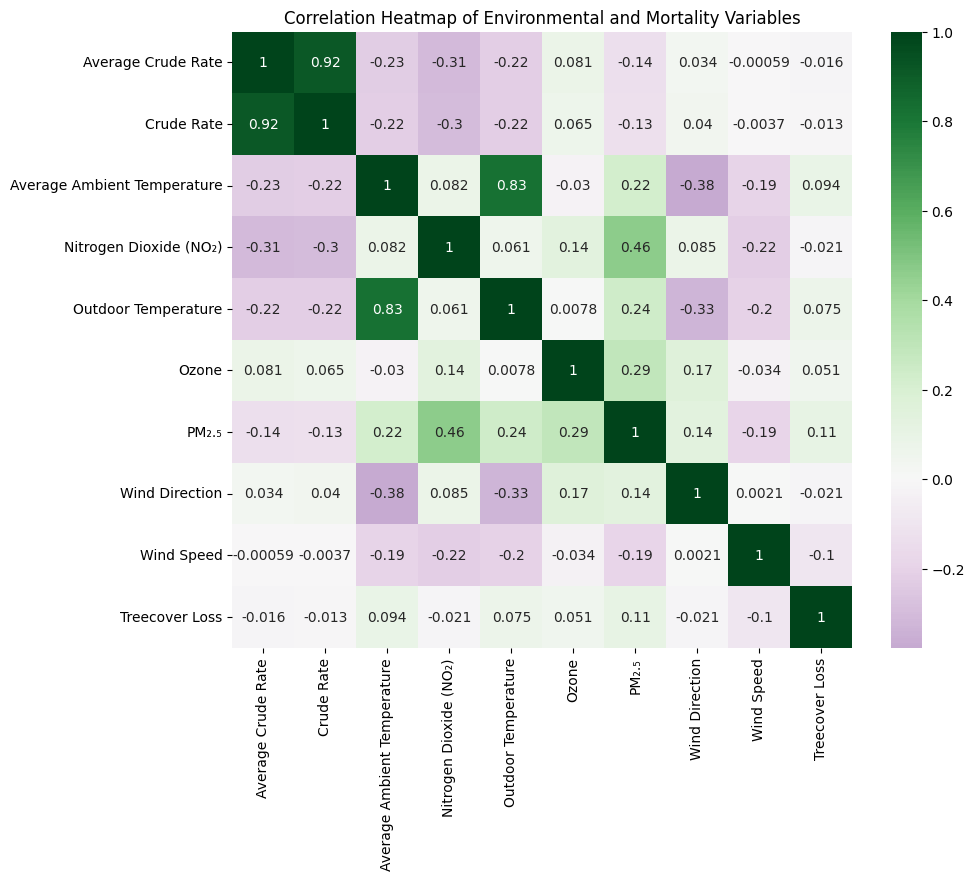

In [ ]:
df = final_master_clean.copy()

df = df.drop(columns=[CountyName, CountyCode, year])
df = df.dropna()

corr = df.corr()


plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="PRGn", center = 0)
plt.title("Correlation Heatmap of Environmental and Mortality Variables")
plt.show()

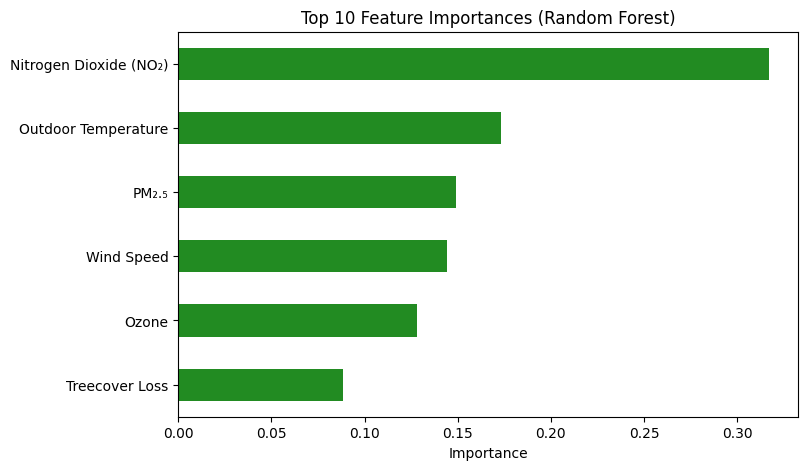

In [ ]:
rf_importance = pd.Series(model.feature_importances_, index=Main_df.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
rf_importance.head(10).sort_values().plot(kind='barh', color = 'forestgreen')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

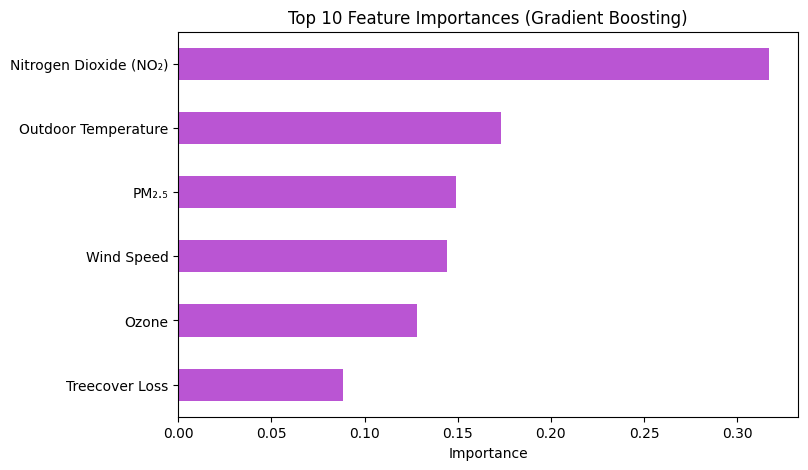

In [ ]:
gb_importance = pd.Series(model.feature_importances_, index=Main_df.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
gb_importance.head(10).sort_values().plot(kind='barh', color = 'mediumorchid')
plt.title("Top 10 Feature Importances (Gradient Boosting)")
plt.xlabel("Importance")
plt.show()

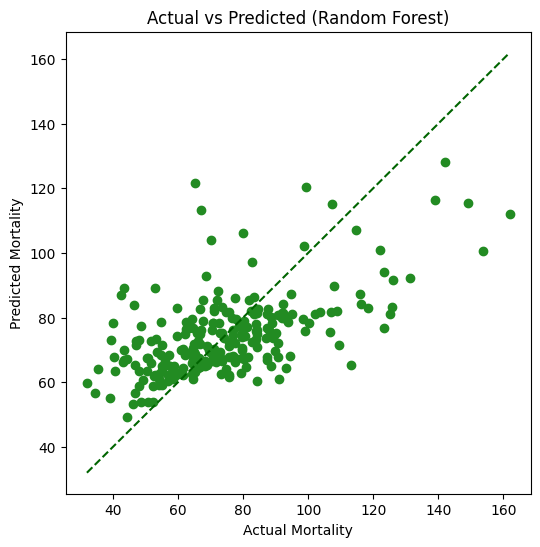

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color = 'forestgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', color = 'darkgreen')
plt.xlabel("Actual Mortality")
plt.ylabel("Predicted Mortality")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

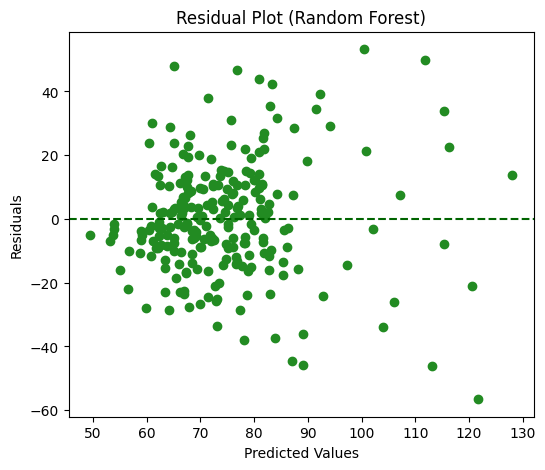

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, color = 'forestgreen')
plt.axhline(0, linestyle='--', color = 'darkgreen')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


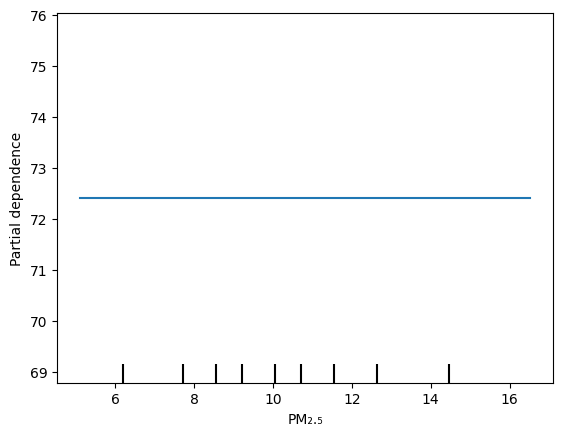

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    model, Main_df, [aqi_pm2_5_local_conditions]
)
plt.show()

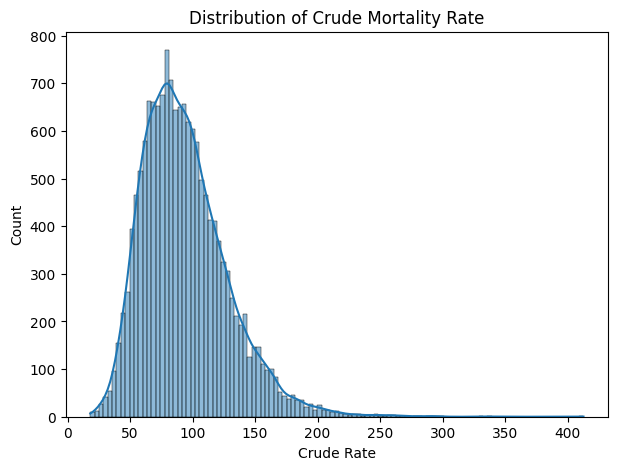

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(final_master_clean[crude_rate], kde=True)
plt.title("Distribution of Crude Mortality Rate")
plt.xlabel(crude_rate)
plt.show()

Regions Code


In [ ]:
region_map = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast', 'RI': 'Northeast',
    'VT': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest',
    'MI': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest',
    'ND': 'Midwest', 'OH': 'Midwest', 'SD': 'Midwest', 'WI': 'Midwest',
    'AL': 'South', 'AR': 'South', 'DE': 'South', 'FL': 'South', 'GA': 'South',
    'KY': 'South', 'LA': 'South', 'MD': 'South', 'MS': 'South', 'NC': 'South',
    'OK': 'South', 'SC': 'South', 'TN': 'South', 'TX': 'South', 'VA': 'South',
    'WV': 'South', 'DC': 'South',
    'AK': 'West', 'AZ': 'West', 'CA': 'West', 'CO': 'West', 'HI': 'West',
    'ID': 'West', 'MT': 'West', 'NV': 'West', 'NM': 'West', 'OR': 'West',
    'UT': 'West', 'WA': 'West', 'WY': 'West',
}

test_df_region = test_df.copy()
test_df_region['state_abbr'] = test_df_region[CountyName].str.extract(r',\s*([A-Z]{2})$')
test_df_region['Region'] = test_df_region['state_abbr'].map(region_map)

print(test_df_region['Region'].value_counts())
print(f"Missing region: {test_df_region['Region'].isna().sum()}")


Region
West         505
South        347
Midwest      231
Northeast    112
Name: count, dtype: int64
Missing region: 0


In [ ]:
feature_cols = [
    aqi_nitrogen_dioxide_no2, aqi_outdoor_temperature, aqi_ozone,
    aqi_pm2_5_local_conditions, aqi_wind_speed_resultant, veg_treecover_loss_ha
]

regions = ['Northeast', 'Midwest', 'South', 'West']
region_results = []

for region in regions:
    subset = test_df_region[test_df_region['Region'] == region].dropna(subset=feature_cols + [crude_rate])

    if len(subset) < 50:
        print(f"\n{region}: only {len(subset)} rows — skipping")
        continue


    print(f"  {region}  (n={len(subset)})")

    X = subset[feature_cols]
    y = subset[crude_rate]
    county_s = subset[CountyName]

    X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(
        X, y, county_s, test_size=0.2, random_state=42
    )
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    gb = GradientBoostingRegressor(
        n_estimators=1000, learning_rate=0.01, max_depth=2,
        validation_fraction=0.1, n_iter_no_change=10, random_state=42
    )
    gb.fit(X_train_sc, y_train)
    gb_pred = gb.predict(X_test_sc)
    gb_imp = pd.Series(gb.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print(f"\n  Gradient Boosting")
    print(f"    Train R2: {gb.score(X_train_sc, y_train):.4f}  Test R2: {gb.score(X_test_sc, y_test):.4f}  MAE: {mean_absolute_error(y_test, gb_pred):.4f}   MAPE: {mean_absolute_error(y_test, gb_pred)} RMSE: {root_mean_squared_error(y_test, gb_pred)}    MedAE: {median_absolute_error(y_test, gb_pred)}")

    rf = RandomForestRegressor(
        n_estimators=500, max_depth=8, min_samples_split=5,
        min_samples_leaf=3, max_features='sqrt', bootstrap=True, random_state=42
    )
    rf.fit(X_train_sc, y_train)
    rf_pred = rf.predict(X_test_sc)
    rf_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print(f"\n  Random Forest")
    print(f"    Train R2: {rf.score(X_train_sc, y_train):.4f}  Test R2: {rf.score(X_test_sc, y_test):.4f}  MAE: {mean_absolute_error(y_test, rf_pred):.4f}   MAPE: {mean_absolute_error(y_test, rf_pred)} RMSE: {root_mean_squared_error(y_test, rf_pred)}    MedAE: {median_absolute_error(y_test, rf_pred)}")

    region_results.append({
        'Region': region, 'n': len(subset),
        'GB_Test_R2': gb.score(X_test_sc, y_test), 'GB_MAE': mean_absolute_error(y_test, gb_pred),
        'RF_Test_R2': rf.score(X_test_sc, y_test), 'RF_MAE': mean_absolute_error(y_test, rf_pred),
        '_gb_pred': gb_pred, '_rf_pred': rf_pred,
        '_y_test': y_test, '_gb_imp': gb_imp, '_rf_imp': rf_imp,
    })


  Northeast  (n=112)

  Gradient Boosting
    Train R2: 0.7053  Test R2: 0.5782  MAE: 10.9278   MAPE: 10.927830253037197 RMSE: 14.362221616957413    MedAE: 5.512460757493116

  Random Forest
    Train R2: 0.8089  Test R2: 0.6647  MAE: 9.1458   MAPE: 9.145752846694373 RMSE: 12.805071517394692    MedAE: 6.94843937435369
  Midwest  (n=231)

  Gradient Boosting
    Train R2: 0.1012  Test R2: 0.1154  MAE: 15.1393   MAPE: 15.139259906409459 RMSE: 20.188895203820312    MedAE: 10.632058334609852

  Random Forest
    Train R2: 0.7411  Test R2: 0.5230  MAE: 12.2391   MAPE: 12.239107685007678 RMSE: 14.825747742116034    MedAE: 10.077907289205697
  South  (n=347)

  Gradient Boosting
    Train R2: 0.6203  Test R2: 0.4060  MAE: 14.7951   MAPE: 14.7950749029943 RMSE: 19.671501611789704    MedAE: 11.662308500971637

  Random Forest
    Train R2: 0.7953  Test R2: 0.5109  MAE: 13.0014   MAPE: 13.001426122701094 RMSE: 17.85092890674051    MedAE: 7.871810749700622
  West  (n=505)

  Gradient Boosting
   

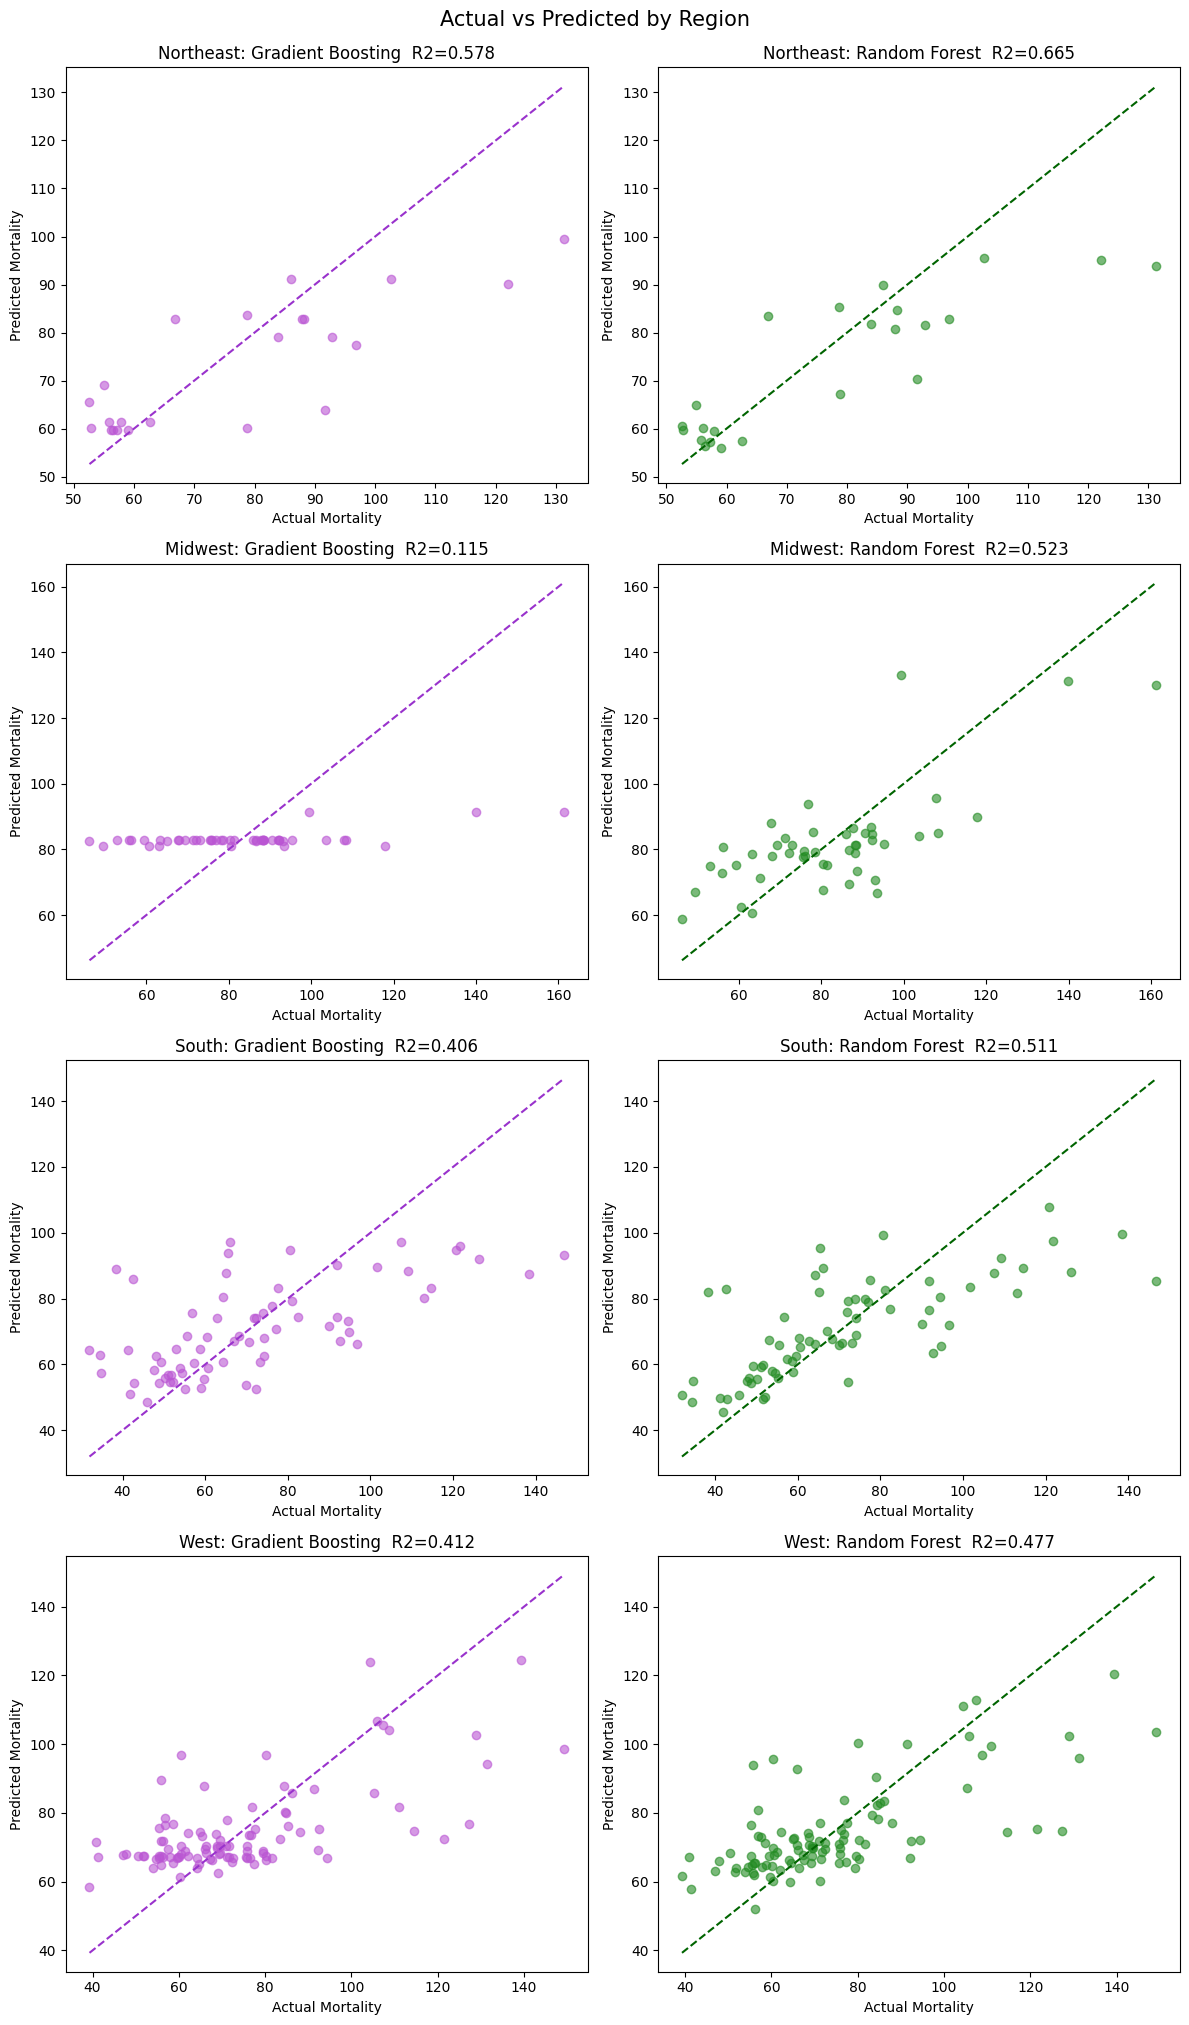

In [ ]:
fig, axes = plt.subplots(len(region_results), 2, figsize=(12, 5 * len(region_results)))

for i, r in enumerate(region_results):
    y_test = r['_y_test']

    axes[i][0].scatter(y_test, r['_gb_pred'], color='mediumorchid', alpha=0.6)
    axes[i][0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='darkorchid')
    axes[i][0].set_xlabel('Actual Mortality'); axes[i][0].set_ylabel('Predicted Mortality')
    axes[i][0].set_title(f"{r['Region']}: Gradient Boosting  R2={r['GB_Test_R2']:.3f}")

    axes[i][1].scatter(y_test, r['_rf_pred'], color='forestgreen', alpha=0.6)
    axes[i][1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='darkgreen')
    axes[i][1].set_xlabel('Actual Mortality'); axes[i][1].set_ylabel('Predicted Mortality')
    axes[i][1].set_title(f"{r['Region']}: Random Forest  R2={r['RF_Test_R2']:.3f}")

plt.tight_layout()
plt.suptitle('Actual vs Predicted by Region', fontsize=15, y=1.01)
plt.show()


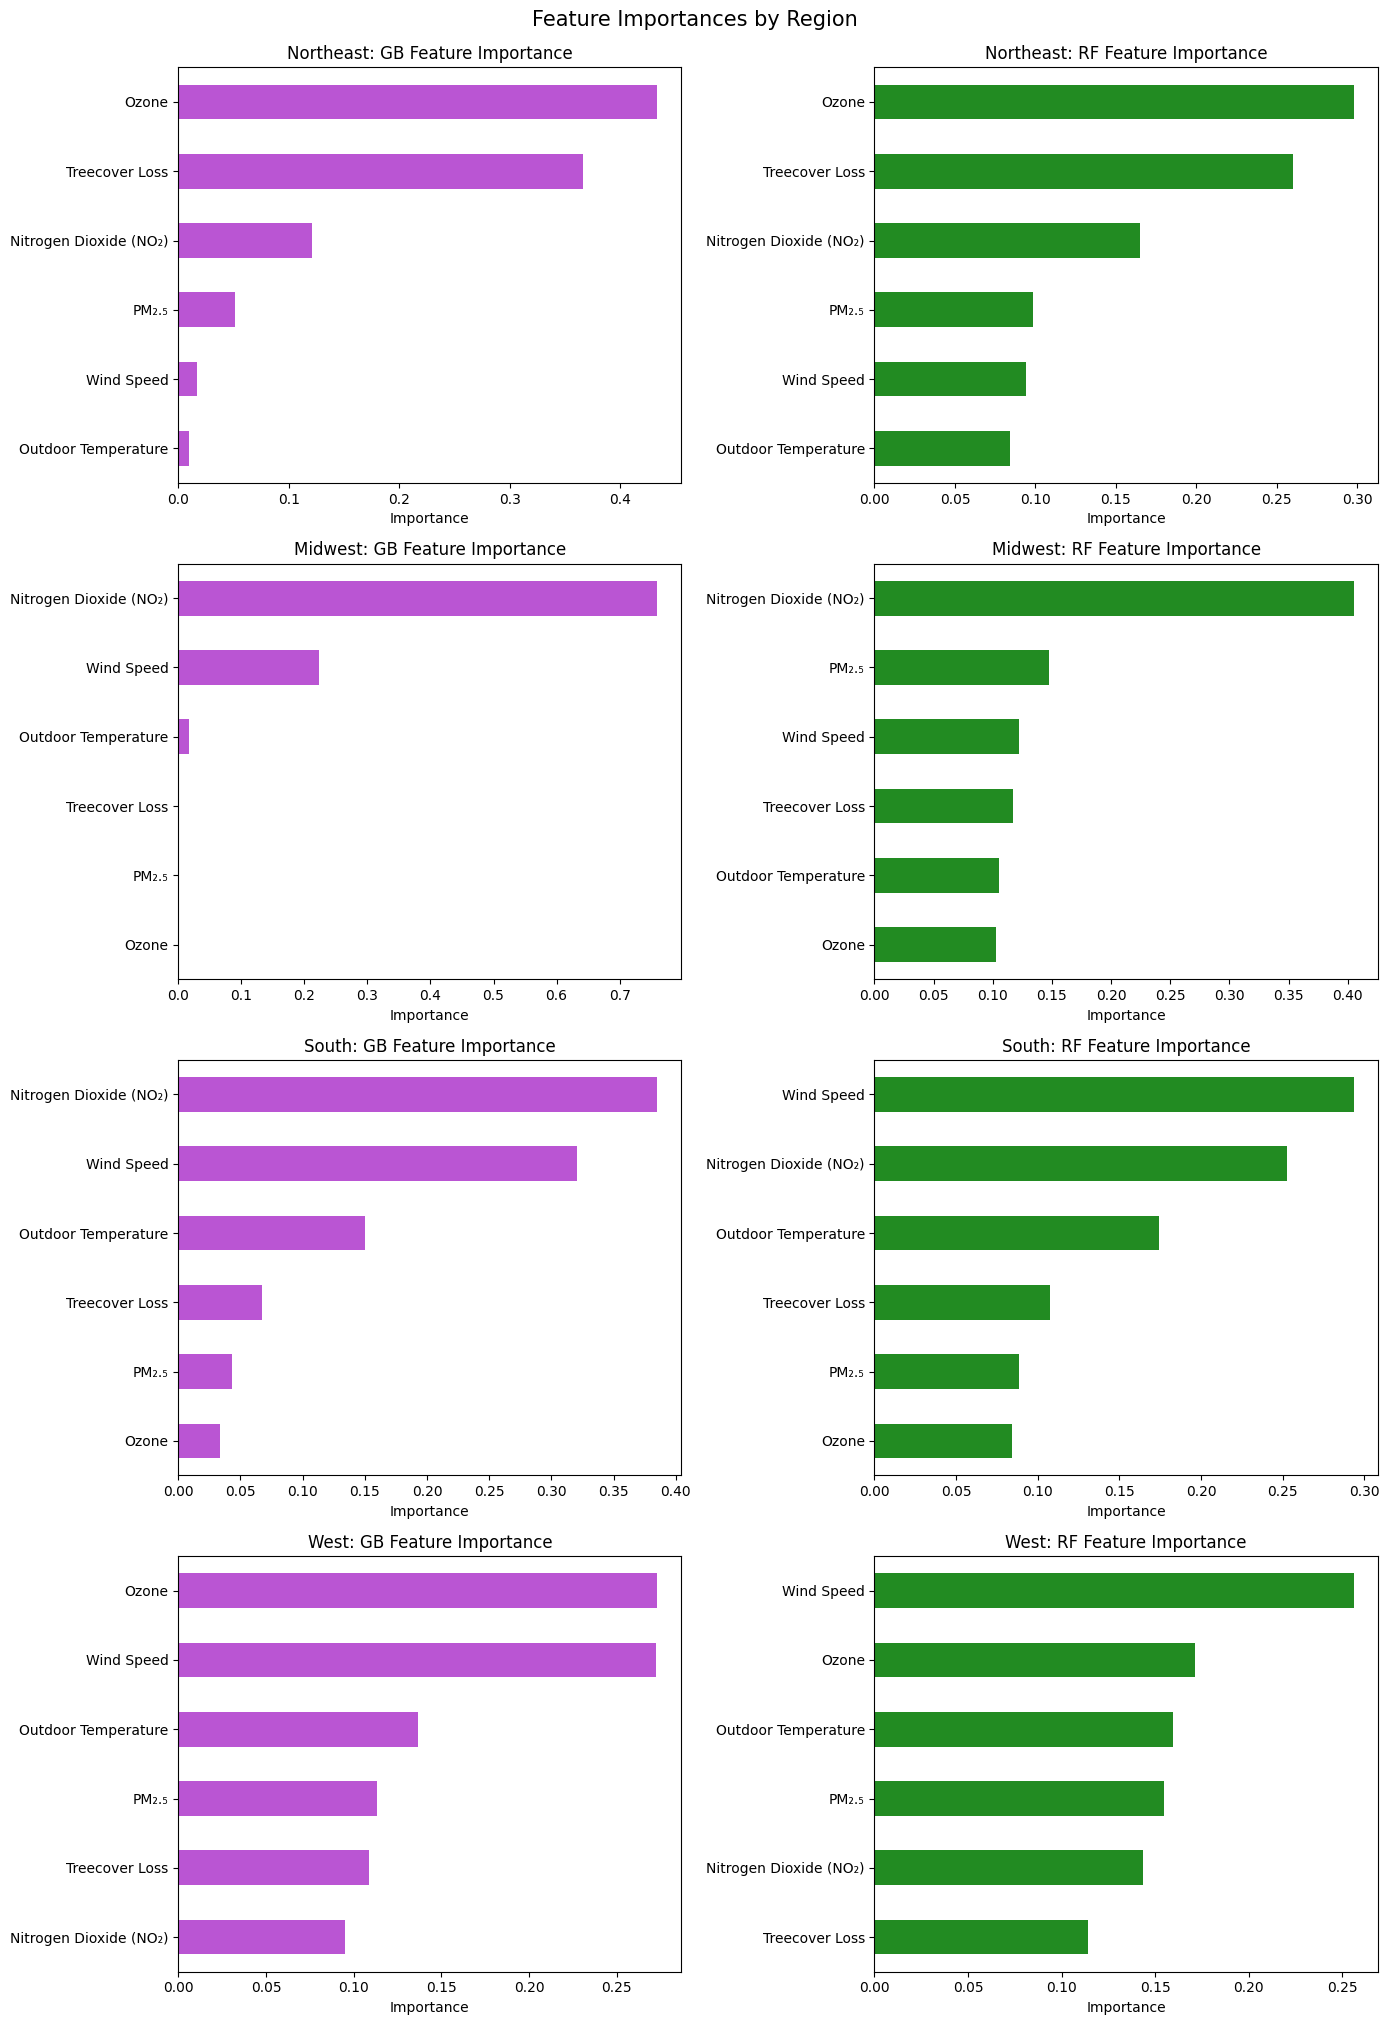

In [ ]:
fig, axes = plt.subplots(len(region_results), 2, figsize=(14, 5 * len(region_results)))

for i, r in enumerate(region_results):
    r['_gb_imp'].sort_values().plot(kind='barh', ax=axes[i][0], color='mediumorchid')
    axes[i][0].set_title(f"{r['Region']}: GB Feature Importance"); axes[i][0].set_xlabel('Importance')

    r['_rf_imp'].sort_values().plot(kind='barh', ax=axes[i][1], color='forestgreen')
    axes[i][1].set_title(f"{r['Region']}: RF Feature Importance"); axes[i][1].set_xlabel('Importance')

plt.tight_layout()
plt.suptitle('Feature Importances by Region', fontsize=15, y=1.01)
plt.show()


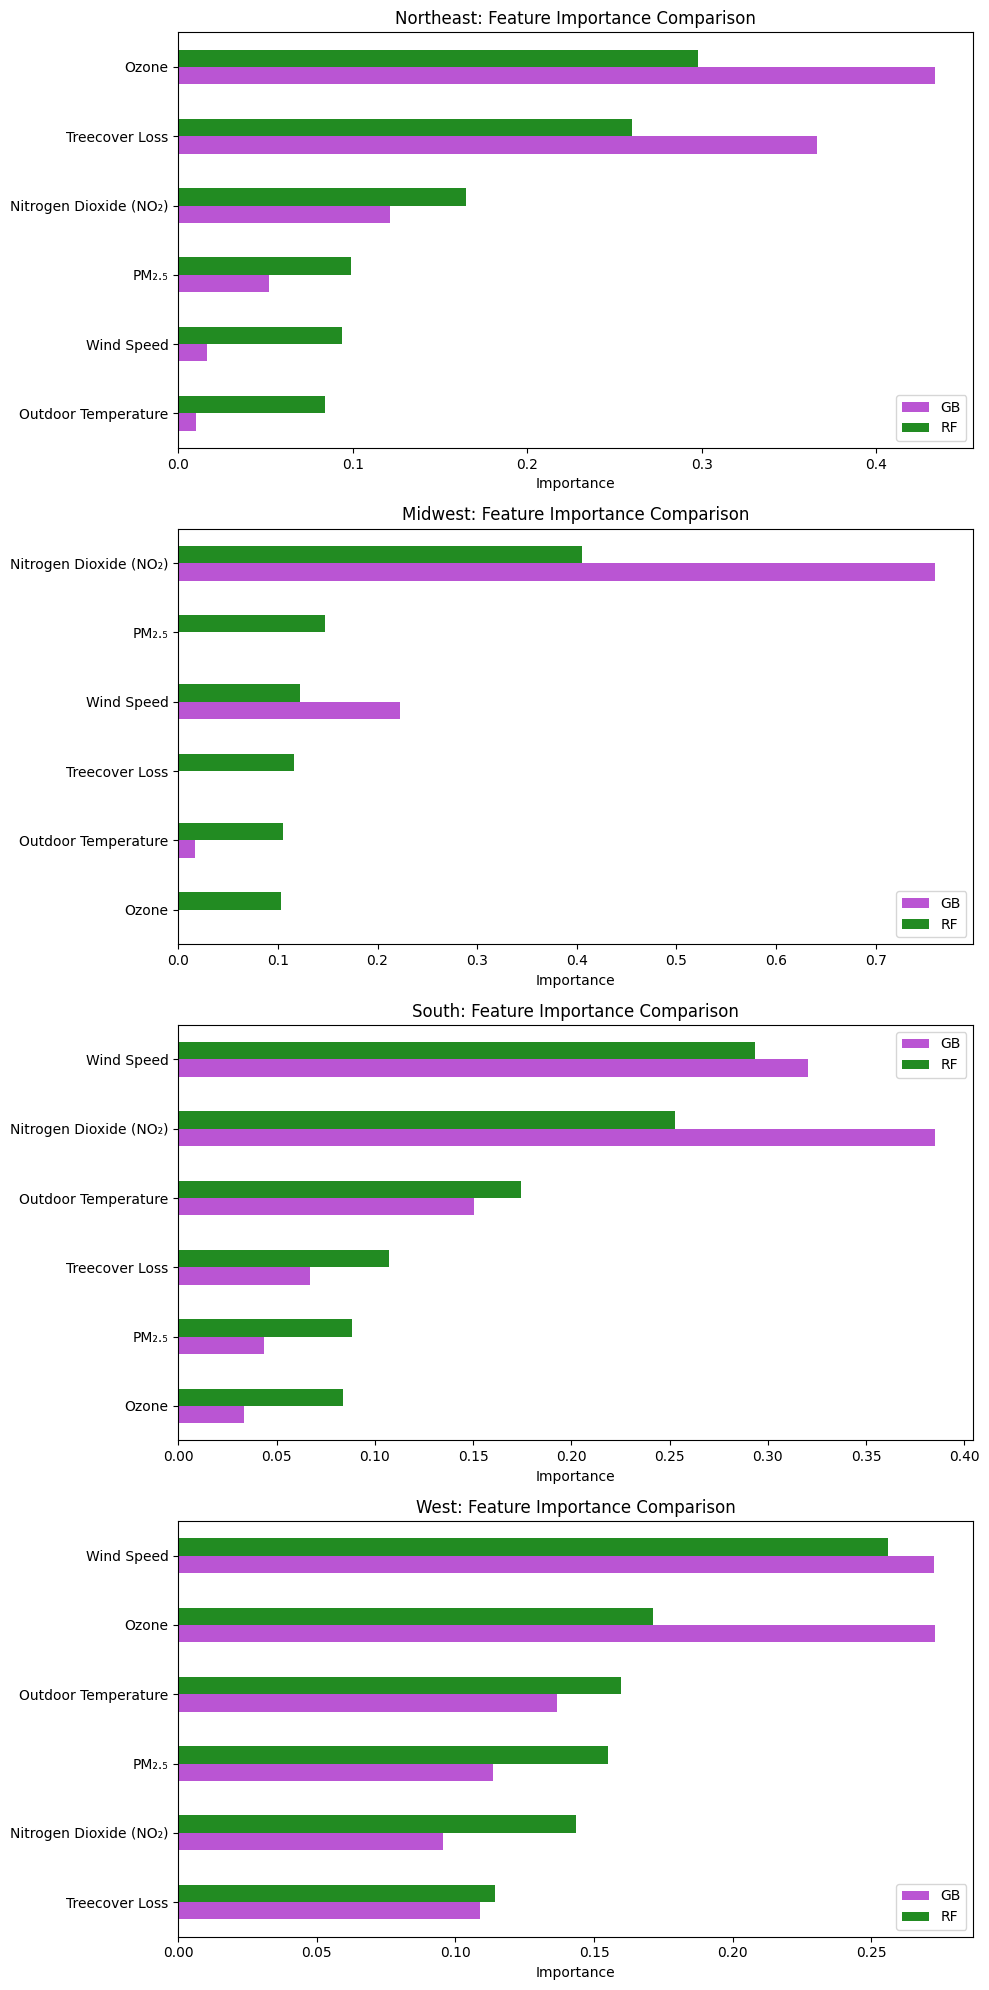

In [ ]:
fig, axes = plt.subplots(len(region_results), 1, figsize=(10, 5 * len(region_results)))

for i, r in enumerate(region_results):
    ax = axes[i] if len(region_results) > 1 else axes

    gb_imp = r['_gb_imp']
    rf_imp = r['_rf_imp']

    df = pd.DataFrame({
        "GB": gb_imp,
        "RF": rf_imp
    })

    df = df.fillna(0)
    df.sort_values("RF").plot(kind="barh", ax=ax, color=["mediumorchid", "forestgreen"])

    ax.set_title(f"{r['Region']}: Feature Importance Comparison")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

Classifier


In [ ]:
target_col = "Crude Rate"

threshold = df[target_col].quantile(0.75)
df["risk_level"] = (df[target_col] >= threshold).astype(int)

print(df["risk_level"].value_counts())

In [ ]:
df["risk_level"].value_counts(normalize=True)

In [ ]:
feature_cols = [
    "Average Ambient Temperature",
    "Nitrogen Dioxide (NO₂)",
    "Outdoor Temperature",
    "Ozone",
    "PM₂.₅",
    "Wind Direction",
    "Wind Speed",
    "Treecover Loss"
]

X = df[feature_cols]
y = df["risk_level"]


In [ ]:
from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

In [ ]:
y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]  # for ROC

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_log))

print("Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

In [ ]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=feature_cols)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.show()